In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize,poly)
from matplotlib.pyplot import subplots
from statsmodels.stats.anova import anova_lm
import math

In [19]:
Carseats = pd.read_csv('./data/Carseats.csv')
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


. Это упражнение должно быть выполнено с использованием набора
данных Carseats.
(a) Выполните подгонку множественной регрессионной модели
для предсказания отклика Sales с использованием предикторов Price, Urban и US

In [35]:
X = Carseats[['Price', 'Urban', 'US']]
urban_one_hot = pd.get_dummies(X['Urban'], prefix='Urban', drop_first=True).astype(int)
us_one_hot = pd.get_dummies(X['US'], prefix='US', drop_first=True).astype(int)

X = X.drop(['Urban', 'US'], axis=1)

X = X.join(urban_one_hot).join(us_one_hot)
X['Intercept'] = 1;

y = Carseats['Sales']

model = sm.OLS(y,X)
results = model.fit()

summarize(results)

,coef,std err,t,P>|t|
Price,-0.0545,0.005,-10.389,0.000
Urban_Yes,-0.0219,0.272,-0.081,0.936
US_Yes,1.2006,0.259,4.635,0.000
Intercept,13.0435,0.651,20.036,0.000


Для какого из предикторов можно отклонить нулевую гипотезу
H0 : βj
 = 0?
Для цены, принадлежности к США и свободного члена, а вот принадлежность к городу скорее всего не особо влияет на отклик

In [36]:
# На основании ответа на предыдущий вопрос выполните подгонку сокращенной модели, в  которой будут присутствовать
# только предикторы, явно влияющие на отклик

X1 = X.copy()
X1 = X1.drop(['Urban_Yes'], axis=1)
X1
model1 = sm.OLS(y, X1)
results1 = model1.fit()

summarize(results1)

,coef,std err,t,P>|t|
Price,-0.0545,0.005,-10.416,0.0
US_Yes,1.1996,0.258,4.641,0.0
Intercept,13.0308,0.631,20.652,0.0


In [37]:
anova_lm(results, results1)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,396.0,2420.834671,0.0,NaN,NaN,NaN
1,397.0,2420.874462,-1.0,-0.03979,0.006525,NaN


Насколько хорошо модели из (a) и (e) описывают данные?
Судя по результатам сравнения моделей, какого-то существенного роста качества из-за исключения показателя
урбан мы не увидели, то есть модели описывают данные  по сути практически одинаково.


In [40]:
# На основе модели из (e) постройте 95-процентные доверительные интервалы для коэффициента(ов).

conf_intervals = results1.conf_int(alpha=0.05)
print(conf_intervals)

                  0          1
Price      -0.06476  -0.044195
US_Yes      0.69152   1.707766
Intercept  11.79032  14.271265


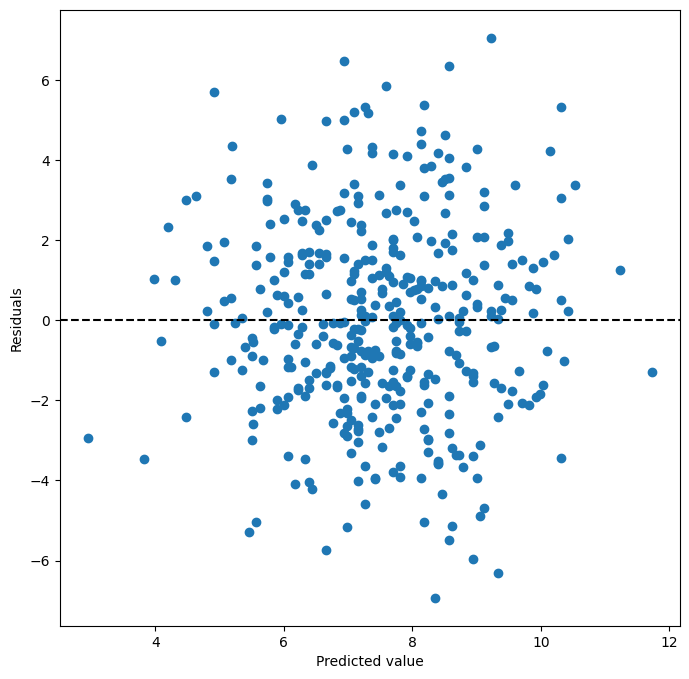

In [41]:
# Присутствуют ли в модели (e) выбросы или наблюдения с высокой разбалансировкой?

ax = subplots(figsize=(8,8))[1]
ax.scatter(results1.fittedvalues, results1.resid)
ax.set_xlabel('Predicted value')
ax.set_ylabel('Residuals')
ax.axhline(0, c='k', ls='--')

Очевидных выбросов нет хотя дисперсия тут солидная. С разбалансировкой ответить затрудняюсь)